<a href="https://colab.research.google.com/github/FutureMove37/McFly-World/blob/main/Copy_of_5b_using_flybody_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/NeLy-EPFL/flygym/blob/v2.1.0/tutorials/5b_using_flybody_model.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> ⚠️ **Running on Google Colab?** Execution there can be **up to ~50× slower** than on a local machine or dedicated GPU, depending on the resources Colab makes available at the time. Use Colab only for testing and following along with the tutorials—not for production runs or benchmarking.

> ⚠️ **FlyBody integration is experimental:** The API may change in future releases.

In [ ]:
# --- Google Colab setup ---
# If you opened this notebook in Google Colab, run this cell first to
# install FlyGym and enable headless (EGL) rendering. It is a no-op when
# the notebook is run anywhere else.
import os
import sys

if "google.colab" in sys.modules:
    os.environ["MUJOCO_GL"] = "egl"
    os.environ["PYOPENGL_PLATFORM"] = "egl"
    %pip install -q tqdm "flygym @ git+https://github.com/NeLy-EPFL/flygym.git@v2.1.0"

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 97.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 97.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 102.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pytensor 2.38.3 requires numba<=0.65.1,>=0.58, but you have nu

# Using the FlyBody model

In this tutorial, we use the **FlyBody** body model — published in [Vaxenburg et al. (2025)](https://www.nature.com/articles/s41586-025-09029-4) ([code](https://github.com/TuragaLab/flybody)) — instead of the default NeuroMechFly model, while retaining the FlyGym API for scene composition, simulation, and control.

We run the same hybrid turning controller from [Tutorial 4d](4d_turning_controller.ipynb) on flat terrain. A two-value descending signal modulates the left/right CPG amplitudes and directions; the hybrid correction rules then produce low-level joint angle and adhesion commands.

One FlyBody-specific detail arises from the **DOF ordering**. `HybridController` builds its joint-angle output using plain `BodySegment`/`RotationAxis`/`JointDOF` types from `flygym.anatomy`, while `fly.get_actuated_jointdofs_order` returns `FlybodyJointDOF` instances. Because frozen dataclasses compare equal only within the same concrete class, we convert the DOF order to plain types before passing it to the controller — the index order is preserved, so the resulting joint-angle array still maps 1-for-1 onto the FlyBody position actuators.

!!! warning "Experimental"
    Support for the FlyBody body model is **experimental**. The API may change in future releases, and not all features available for the default NeuroMechFly model are currently supported.


In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from tqdm import trange

from flygym import Simulation
from flygym.anatomy import BodySegment, JointDOF, RotationAxis
from flygym.compose import ActuatorType, FlatGroundWorld, KinematicPosePreset
from flygym.compose.fly import FlyBody
from flygym.flybody import (
    FlyBodyActuatedDOFPreset,
    FlyBodyAxisOrder,
    FlyBodyContactBodiesPreset,
    FlyBodyJointPreset,
    FlyBodySkeleton,
    FlyBodyBodySegment,
)
from flygym.utils.math import Rotation3D
from flygym_demo.complex_terrain import (
    HybridControllerObservation,
    HybridTurningController,
    FlyBodyPreprogrammedSteps,
    apply_locomotion_action,
)
from flygym_demo.complex_terrain.common import LocomotionAction

output_dir = Path("demo_output/flybody_turning_controller")
output_dir.mkdir(parents=True, exist_ok=True)

## Build the FlyBody fly

Legs-only joints, position-controlled active leg DoFs, and leg adhesion — same active DOF layout (42 position actuators, 6 adhesion outputs) as the standard locomotion fly, but using the FlyBody skeleton, axis convention, and neutral pose.

In [ ]:
axis_order = FlyBodyAxisOrder.YAW_ROLL_PITCH
neutral_pose = KinematicPosePreset.FLYBODY_NEUTRAL

fly = FlyBody(name="flybody")
skeleton = FlyBodySkeleton(
    axis_order=axis_order,
    joint_preset=FlyBodyJointPreset.LEGS_ONLY,
)
fly.add_joints(skeleton, neutral_pose)

actuated_dofs = fly.skeleton.get_actuated_dofs_from_preset(
    FlyBodyActuatedDOFPreset.LEGS_ACTIVE_ONLY
)
fly.add_actuators(actuated_dofs, ActuatorType.POSITION, kp=100)
fly.add_leg_adhesion()
fly.colorize()

body_cam = fly.add_tracking_camera(
    name="body_cam",
    pos_offset=(0.0, -8.0, 0.0),
    rotation=Rotation3D("euler", (1.57, 0.0, 0.0)),
    fovy=35.0,
)

world = FlatGroundWorld()
world.add_fly(
    fly,
    [0, 0, 0.7],
    Rotation3D("quat", [1, 0, 0, 0]),
    bodysegs_with_ground_contact=FlyBodyContactBodiesPreset.TIBIA_TARSUS_ONLY,
    add_ground_contact_sensors=False,
)

sim = Simulation(world)
renderer = sim.set_renderer(
    [body_cam],
    camera_res=(240, 320),
    playback_speed=0.1,
    output_fps=25,
)

2026-09-13 08:20:40.035 | INFO     | flygym.utils.assets_lazy_loading:_download_prefix:171 - Downloading 87 FlyGym asset file(s) (140.2 MB) from S3 to /root/.cache/flygym_assets/tmpuku66ame.partial (one-time download)...
2026-09-13 08:25:28.012 | INFO     | flygym.utils.assets_lazy_loading:_download_prefix:177 - Finished downloading FlyGym assets.


## Build the controller — converting the DOF order

`fly.get_actuated_jointdofs_order(POSITION)` returns FlyBody-typed `FlybodyJointDOF` objects. The hybrid controller builds an internal `dict[JointDOF, angle]` using plain `JointDOF(BodySegment, BodySegment, RotationAxis)` keys, so we rebuild the order with the plain types. Because we only rebuild the element types (not the order), the resulting joint-angle array still lines up with the FlyBody position actuators index-by-index.

In [ ]:
def to_plain_dof_order(flybody_dof_order):
    """Cast a list of FlyBodyJointDOF into plain JointDOF, preserving order."""
    return [
        JointDOF(
            BodySegment(d.parent.name),
            BodySegment(d.child.name),
            RotationAxis(d.axis.value),
        )
        for d in flybody_dof_order
    ]


flybody_dof_order = fly.get_actuated_jointdofs_order(ActuatorType.POSITION)
controller_dof_order = to_plain_dof_order(flybody_dof_order)

preprogrammed_steps = FlyBodyPreprogrammedSteps()
controller = HybridTurningController(
    timestep=sim.timestep,
    preprogrammed_steps=preprogrammed_steps,
    output_dof_order=controller_dof_order,
    enable_adhesion=False,  # disable adhesion as somehow it leads to the fly rearing ???
)

print("Position actuators:", len(flybody_dof_order))
print("Simulation timestep:", sim.timestep)

Position actuators: 42
Simulation timestep: 0.0001


## Apply the initial pose

In [ ]:
sim.reset()
controller.reset(seed=0)

initial_action = LocomotionAction(
    joint_angles=preprogrammed_steps.default_pose_by_dof_order(controller_dof_order),
    adhesion_onoff=np.ones(6, dtype=bool),
)

apply_locomotion_action(sim, fly.name, initial_action)
sim.warmup()

## Run the turning controller

Descending command turns one way for the first half of the run, then the other way.

In [ ]:
run_time = 2.0
nsteps_sim = int(run_time / sim.timestep)
time_grid = np.arange(nsteps_sim) * sim.timestep

thorax_idx = fly.get_bodysegs_order().index(FlyBodyBodySegment("c_thorax"))
thorax_positions = np.full((nsteps_sim, 3), np.nan, dtype=np.float32)
cpg_magnitudes = np.full((nsteps_sim, 6), np.nan, dtype=np.float32)
descending_signals = np.full((nsteps_sim, 2), np.nan, dtype=np.float32)

for step_idx in trange(nsteps_sim, desc="Running flybody turning controller"):
    curr_time = step_idx * sim.timestep
    if curr_time < run_time / 2:
        descending_signal = np.array([0.4, 1.2])
    else:
        descending_signal = np.array([1.2, 0.4])

    obs = HybridControllerObservation.from_sim(sim, fly.name)
    action = controller.step(descending_signal, obs)
    apply_locomotion_action(sim, fly.name, action)
    sim.step_with_profile()

    thorax_positions[step_idx] = sim.get_body_positions(fly.name)[thorax_idx]
    cpg_magnitudes[step_idx] = controller.cpg_network.curr_magnitudes
    descending_signals[step_idx] = descending_signal

    sim.render_as_needed_with_profile()

print("Rendered frames:", len(renderer.frames[body_cam.name]))
print(
    "Final thorax displacement:",
    np.round(thorax_positions[-1] - thorax_positions[0], 3),
    "mm",
)
sim.print_performance_report()

Running flybody turning controller: 100%|██████████| 20000/20000 [02:48<00:00, 118.90it/s]

Rendered frames: 500
Final thorax displacement: [-1.8000e-02  1.8226e+01 -9.8000e-02] mm

                                   PERFORMANCE PROFILE                                    
┌────────────────────────────────┬─────────────┬───────────┬──────────────┬──────────────┐
│                                │   Time/step │   Percent │   Throughput │   Throughput │
│ Stage                          │        (us) │       (%) │    (iters/s) │   x realtime │
├────────────────────────────────┼─────────────┼───────────┼──────────────┼──────────────┤
│ Physics simulation advancement │         408 │         6 │         2452 │         0.25 │
├────────────────────────────────┼─────────────┼───────────┼──────────────┼──────────────┤
│ Rendering*                     │        6028 │        94 │          166 │         0.02 │
├────────────────────────────────┼─────────────┼───────────┼──────────────┼──────────────┤
│ TOTAL                          │        6436 │       100 │          155 │         0.02 │


In [ ]:
sim.renderer.show_in_notebook()
sim.renderer.save_video(output_dir / "flybody_turning_controller.mp4")

flybody/body_cam This browser does not support the video tag.


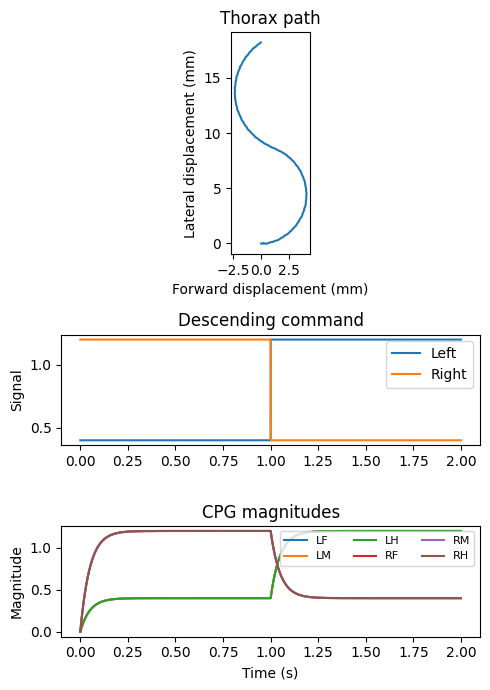

In [ ]:
fig, axes = plt.subplots(
    3, 1, figsize=(5, 7), tight_layout=True, height_ratios=[2, 1, 1]
)

axes[0].plot(
    thorax_positions[:, 0] - thorax_positions[0, 0],
    thorax_positions[:, 1] - thorax_positions[0, 1],
)
axes[0].set_aspect("equal", adjustable="box")
axes[0].set_xlabel("Forward displacement (mm)")
axes[0].set_ylabel("Lateral displacement (mm)")
axes[0].set_title("Thorax path")

axes[1].plot(time_grid, descending_signals[:, 0], label="Left")
axes[1].plot(time_grid, descending_signals[:, 1], label="Right")
axes[1].set_ylabel("Signal")
axes[1].set_title("Descending command")
axes[1].legend()

for leg_idx, leg in enumerate(preprogrammed_steps.legs):
    axes[2].plot(time_grid, cpg_magnitudes[:, leg_idx], label=leg.upper())
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("Magnitude")
axes[2].set_title("CPG magnitudes")
axes[2].legend(ncols=3, fontsize=8)

fig.savefig(output_dir / "flybody_turning_controller_diagnostics.png")